# Efficient Frontier - Modern Portfolio Theory

This notebook explores Markowitz's Modern Portfolio Theory (1952), which answers the question: given a set of assets, what is the optimal way to allocate money between them? 

The key insight is that combining assets reduces risk through diversification - assets that move independently (or oppositely) partially cancel out each other's volatility, giving a better risk-adjusted return than any single asset alone. 

For a portfolio with weights $\mathbf{w}$, the expected return and 
volatility are:

$$\mu_p = \mathbf{w}^T \boldsymbol{\mu}$$

$$\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}$$

where $\Sigma$ is the covariance matrix capturing how assets move 
together.


In [1]:
!mamba install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
os.makedirs('images', exist_ok=True)

def portfolio_return(weights,mu):
    return np.dot(weights,mu)
    
def portfolio_volatility(weights,cov):
    return np.sqrt(weights @ cov @ weights)

def generate_random_weights(n_assets):
    w = np.random.random(n_assets)
    return w/w.sum()
    
def simulate_portfolios(mu,cov,n_portfolios = 10000, risk_free_rate = 0.02):
    n_assets = len(mu)
    results = []
    all_weights = []
    for n in range(n_portfolios):
        w = generate_random_weights(n_assets)
        ret = portfolio_return(w,mu)
        vol = portfolio_volatility(w,cov)
        sharpe = (ret - risk_free_rate) / vol
        results.append([ret,vol,sharpe])
        all_weights.append(w)
    return np.array(results) , np.array(all_weights)

/bin/bash: mamba: command not found


## 1. The Assets 

We define four stocks with different risk and return profiles:

| Stock | Expected Return | Volatility | Character |
|-------|----------------|------------|-----------|
| 1     | 10%            | 15%        | Moderate  |
| 2     | 12%            | 20%        | Growth    |
| 3     | 7%             | 10%        | Safe      |
| 4     | 15%            | 25%        | Aggressive|

The correlation matrix captures how the stocks move together. Stocks 2 and 3 are slightly negatively correlated - they provide good diversification against each other.

In [2]:
weights = np.array([0.25,0.25,0.25,0.25])
# expected annual returns
mu = np.array([0.10, 0.12, 0.07, 0.15])
# annual volatilities
sigma = np.array([0.15,0.20,0.10,0.25])
#correlation matrix - how stocks move together
corr = np.array([
    [1.00, 0.20, 0.10, 0.30],
    [0.20, 1.00, -0.10, 0.40],
    [0.10, -0.10, 1.00, 0.05],
    [0.30, 0.40, 0.05, 1.00]])
cov = corr*np.outer(sigma,sigma)

## 2. Correlation Structure

Before building portfolios it's important to understand how the assets relate to each other. The heatmap below shows the correlation between every pair of stocks. 

Red cells indicate positive correlation - stocks tend to move together. Blue cells indidicate negative correlation - stocks tend to move in opposite directions. Negatively correlated assets are the most valuable for diversification. 

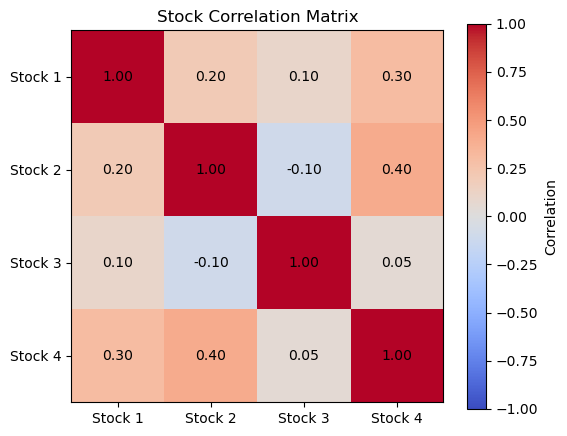

In [3]:
plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title('Stock Correlation Matrix')

# add labels on axes
labels = ['Stock 1', 'Stock 2', 'Stock 3', 'Stock 4']
plt.xticks(np.arange(4), labels)
plt.yticks(np.arange(4), labels)

# add the actual numbers inside each cell
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{corr[i,j]:.2f}', 
                ha='center', va='center', color='black')
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. The Efficient Frontier

We generate 10,000 random portfolios by sampling random weight combinatinos. Each portfolio is plotted with volatility on teh x-axis and return on the y-axis, coloured by its Sharpe ratio. 

The efficient frontier is the glowing edge along the top left of the colour - portfolios that deliver the maximum return for a given level of risk. Any portfolio below this edge is suboptimal. 

Notice that all four individual stocks sit in the interior of the clour - diversification always dominates holding any single asset. 

Optimal Portfolio Weights:
 Stock 1: 21.25%
 Stock 2: 20.27%
 Stock 3: 50.89%
 Stock 4: 7.60%
Expected Return: 9.26%'
Volatility: 8.43%
Sharpe Ratio: 0.8606


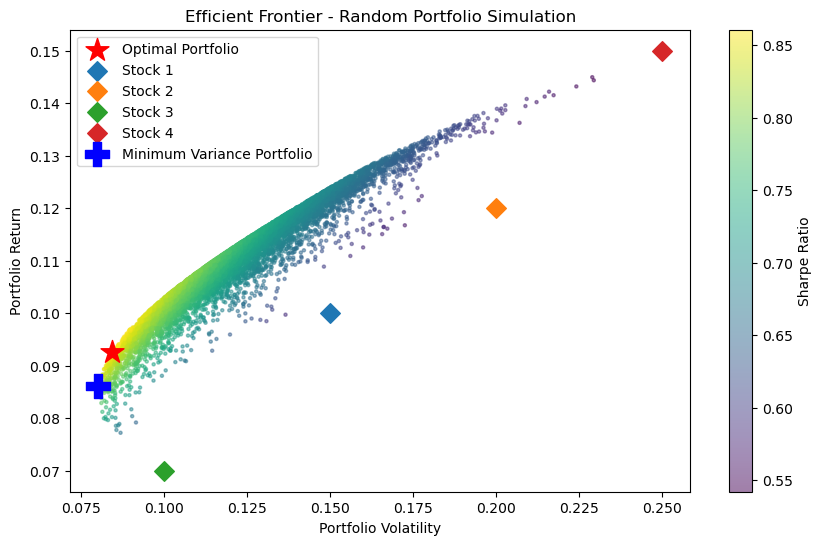

In [4]:
results, all_weights = simulate_portfolios(mu,cov)
best_idx = np.argmax(results[:,2])
best_ret = results[best_idx,0]
best_vol = results[best_idx,1]
best_weights = all_weights[best_idx]
print('Optimal Portfolio Weights:')
for i,w in enumerate(best_weights):
    print(f" Stock {i+1}: {w:.2%}")
print(f"Expected Return: {best_ret:.2%}'")
print(f"Volatility: {best_vol:.2%}")
print(f"Sharpe Ratio: {results[best_idx, 2]:.4f}")
plt.figure(figsize = (10,6))
scatter = plt.scatter(results[:,1] , results[: , 0], c = results[:,2], cmap = 'viridis', alpha = 0.5, s=5)
plt.colorbar(scatter, label = 'Sharpe Ratio')
plt.xlabel('Portfolio Volatility')
plt.ylabel('Portfolio Return')
plt.title('Efficient Frontier - Random Portfolio Simulation')
plt.scatter(best_vol, best_ret, color = 'red', marker = '*', s = 300, label = 'Optimal Portfolio')
for i in range(len(mu)):
    plt.scatter(sigma[i], mu[i], marker = 'D', s=100, label = f'Stock {i+1}')
min_vol_idx = np.argmin(results[:,1])
min_vol_ret = results[min_vol_idx, 0]
min_vol_vol = results[min_vol_idx,1]
plt.scatter(min_vol_vol, min_vol_ret, color = 'blue', marker = 'P', s=300, label = 'Minimum Variance Portfolio')
plt.legend()
plt.savefig('images/efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show() 

## 4. Optimal Portfolios

Two portfolios of particular interest:

- **Maximum Sharpe Portfolio** - the best risk-adjusted return. This is the theoretically optimal portfolio for an investor who wants to maximise return per unit of risk.

- **Minimum Variance Portfolio** - the lowest possible volatility regardless of return. Optimal for an investor whose only goal is safety.

Both portfolios are heavily weighted toward Stock 3 - despite its low individual return, its low volatility and low correlations make it the most valuable diversifier in the portfolio. 

In [5]:
rows = []
rows.append({
    "Portfolio": "Optimal (Max Sharpe)",
    "Return": best_ret,
    "Volatility": best_vol,
    "Sharpe": results[best_idx, 2],
    "Stock 1 Weight": all_weights[best_idx, 0],
    "Stock 2 Weight": all_weights[best_idx, 1],
    "Stock 3 Weight": all_weights[best_idx, 2],
    "Stock 4 Weight": all_weights[best_idx, 3],
})
rows.append({
    "Portfolio": "Safest (Min Volatility)",
    "Return": min_vol_ret,
    "Volatility": min_vol_vol,
    "Sharpe": results[min_vol_idx, 2],
    "Stock 1 Weight": all_weights[min_vol_idx, 0],
    "Stock 2 Weight": all_weights[min_vol_idx, 1],
    "Stock 3 Weight": all_weights[min_vol_idx, 2],
    "Stock 4 Weight": all_weights[min_vol_idx, 3],
})

df = pd.DataFrame(rows).set_index("Portfolio")

display(df.style.format({
    "Return": "{:.4f}",
    "Volatility": "{:.4f}",
    "Sharpe": "{:.4f}",
    "Stock 1 Weight": "{:.2%}",
    "Stock 2 Weight": "{:.2%}",
    "Stock 3 Weight": "{:.2%}",
    "Stock 4 Weight": "{:.2%}",
}))



,Return,Volatility,Sharpe,Stock 1 Weight,Stock 2 Weight,Stock 3 Weight,Stock 4 Weight
Portfolio,,,,,,,
Optimal (Max Sharpe),0.0926,0.0843,0.8606,21.25%,20.27%,50.89%,7.60%
Safest (Min Volatility),0.0861,0.0801,0.8247,21.23%,16.83%,60.32%,1.62%
